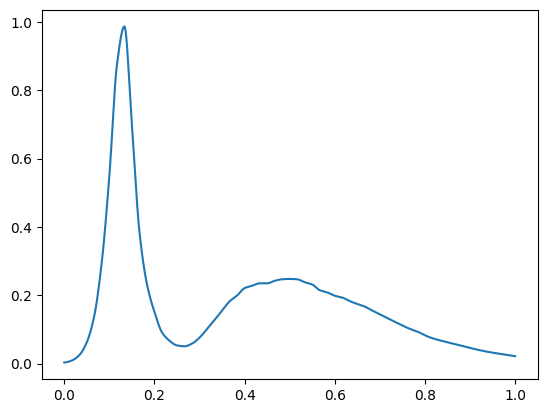

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from pathlib import Path

csv_path = Path("../configs/mcwhl5_spectrum_digitized_from_plot_5nm.csv")
spec = pd.read_csv(csv_path)

lam_data = spec["wavelength_nm"].to_numpy()
S_data = spec["normalized_intensity"].to_numpy()

lam_normalized = (lam_data - lam_data.min())/(lam_data.max() - lam_data.min())

S = PchipInterpolator(lam_normalized, S_data, extrapolate=False)

lam = np.linspace(400, 700, 2000)
lam_1 = np.linspace(0, 1, 2000)
S_lam = S(lam_1) # np.clip(S(lam), 0, None)


import matplotlib.pyplot as plt
plt.plot(lam_1,S_lam)
plt.show()